<a href="https://colab.research.google.com/github/Siddharth5723/Daily_learning/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Principal Component Analysis (PCA) Notebook

Principal Component Analysis (PCA) is a popular technique for dimensionality reduction. It transforms a high-dimensional dataset into a lower-dimensional one while retaining most of the important information. This notebook will walk you through the steps of performing PCA on a sample dataset.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## 2. Generate Sample Data

To illustrate PCA, we'll create a synthetic dataset with some correlation between features.

In [2]:
np.random.seed(42)

# Number of samples and features
n_samples = 100
n_features = 3

# Create correlated features
X = np.random.randn(n_samples, n_features)
X[:, 0] = X[:, 0] * 3 + 5 # Feature 1 (larger variance, centered at 5)
X[:, 1] = X[:, 1] * 2 + X[:, 0] * 0.7 # Feature 2 (correlated with Feature 1)
X[:, 2] = X[:, 2] * 1.5 - X[:, 0] * 0.5 + X[:, 1] * 0.3 # Feature 3 (correlated with Feature 1 and 2)

df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2', 'Feature_3'])
display(df.head())

,Feature_1,Feature_2,Feature_3
0,6.490142,4.266571,-0.993567
1,9.569090,6.230056,-3.266733
2,9.737638,8.351216,-3.067666
3,6.627680,3.712541,-2.898672
4,5.725887,0.181560,-5.395852


## 3. Data Exploration (Optional)

Let's visualize the relationships between our features using a pairplot. This helps us see any initial correlations.

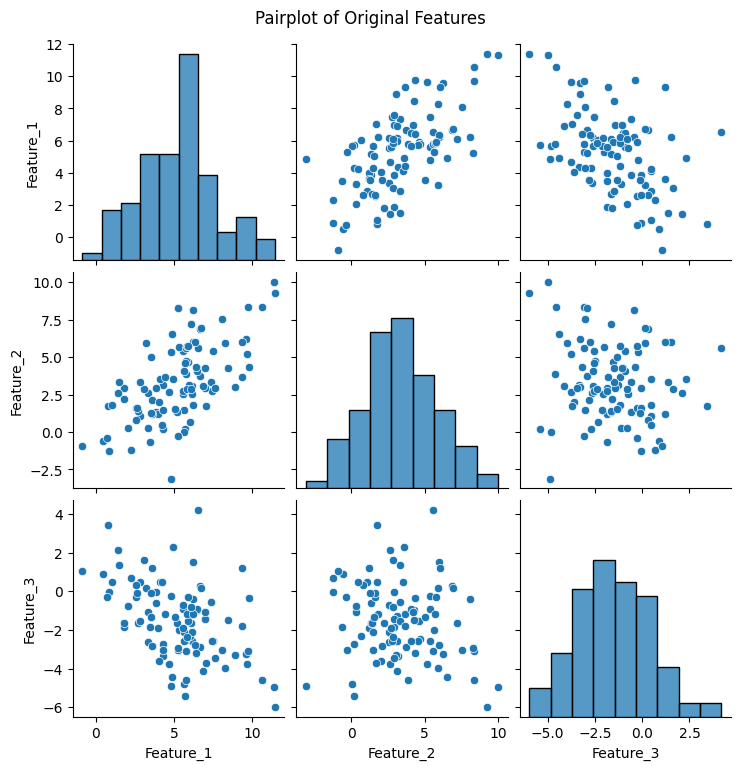

In [3]:
sns.pairplot(df)
plt.suptitle('Pairplot of Original Features', y=1.02) # Add a title to the pairplot
plt.show()

## 4. Standardize the Data

PCA is affected by scale. Features with larger variances will dominate the principal components if the data is not scaled. Therefore, it's crucial to standardize the data (mean=0, variance=1) before applying PCA.

In [4]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_features, columns=df.columns)
display(scaled_df.head())
print(f"Mean of scaled features: {scaled_df.mean().mean():.2f}")
print(f"Standard deviation of scaled features: {scaled_df.std().mean():.2f}")

,Feature_1,Feature_2,Feature_3
0,0.493439,0.370551,0.277717
1,1.744030,1.144292,-0.904540
2,1.812490,1.980168,-0.801006
3,0.549304,0.152227,-0.713114
4,0.183018,-1.239210,-2.011879


Mean of scaled features: 0.00
Standard deviation of scaled features: 1.01


## 5. Apply PCA

Now, we'll apply PCA to the standardized data. We can start by fitting PCA to all components to understand the explained variance.

In [5]:
pca = PCA()
pca.fit(scaled_features)

# Explained variance ratio for each principal component
explained_variance_ratio = pca.explained_variance_ratio_
print(f"Explained Variance Ratio: {explained_variance_ratio}")

# Cumulative explained variance
cum_explained_variance = np.cumsum(explained_variance_ratio)
print(f"Cumulative Explained Variance: {cum_explained_variance}")

Explained Variance Ratio: [0.63124763 0.27952152 0.08923085]
Cumulative Explained Variance: [0.63124763 0.91076915 1.        ]


## 6. Determine Number of Components (Scree Plot)

The explained variance ratio tells us how much variance each principal component captures. A common way to decide on the number of components is to plot the explained variance and look for an 'elbow' point where the gain in explained variance diminishes significantly.

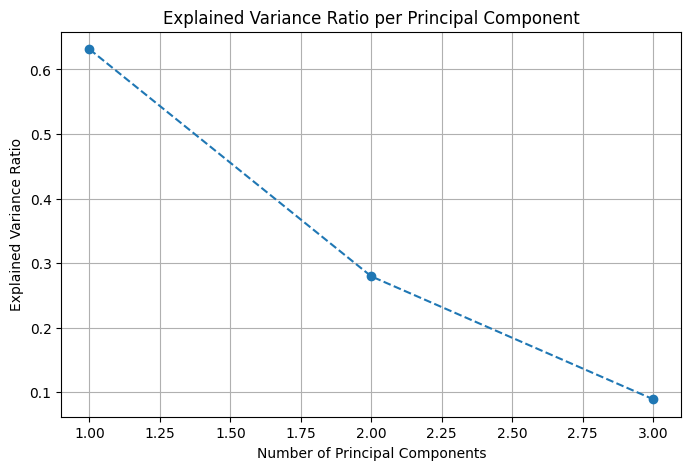

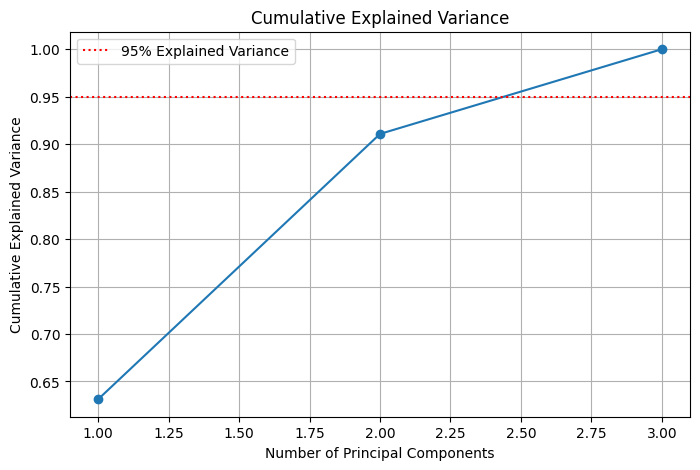

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.title('Explained Variance Ratio per Principal Component')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_explained_variance) + 1), cum_explained_variance, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle=':', label='95% Explained Variance')
plt.grid(True)
plt.legend()
plt.show()

From the plots, we can see how many components are needed to explain a certain amount of variance. For example, to retain 95% of the variance, we might choose a specific number of components.

## 7. Transform Data to Principal Components

Let's choose a number of components (e.g., 2, as our sample data is 3D and 2 components likely capture most variance) and transform the data.

In [7]:
n_components = 2 # Based on the explained variance plots
pca = PCA(n_components=n_components)
pca_features = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(data=pca_features, columns=[f'Principal Component {i+1}' for i in range(n_components)])
display(pca_df.head())

,Principal Component 1,Principal Component 2
0,0.410185,0.472580
1,2.251055,0.062118
2,2.724576,0.647746
3,0.793586,-0.447357
4,0.371125,-2.338667


## 8. Visualize PCA Results

With two principal components, we can easily visualize the reduced-dimensional data.

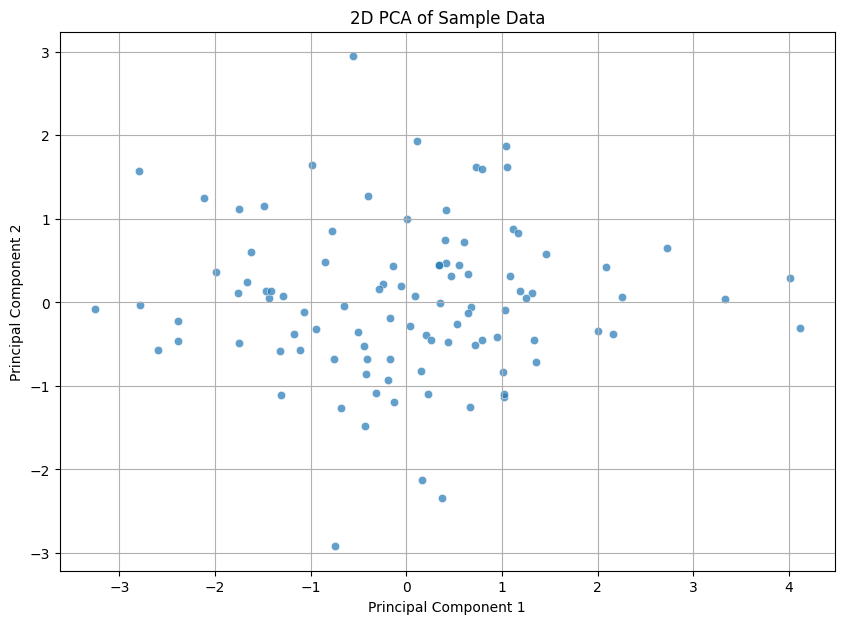

In [8]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', data=pca_df, alpha=0.7)
plt.title('2D PCA of Sample Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## Conclusion

This notebook demonstrated the basic steps of Principal Component Analysis:
1.  **Generating sample data** with correlated features.
2.  **Standardizing the data** to ensure all features contribute equally.
3.  **Applying PCA** to find the principal components.
4.  **Analyzing the explained variance** to select the optimal number of components.
5.  **Transforming the data** into the new, lower-dimensional space.
6.  **Visualizing the results** to understand the data's structure in the reduced dimensions.

PCA is a powerful tool for simplifying complex datasets, visualizing high-dimensional data, and reducing noise, making it easier for subsequent machine learning algorithms to process.